#### Name: Anshupriya Kumar
#### Batch: A1
#### Roll No: 16


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
df = pd.read_csv('earbuds_reviews_large.csv')
df.head(5)

,brand,product,review,rating,sentiment
0,boAt,Airdopes Alpha,The sound quality is really satisfying during ...,5,Positive
1,JBL,Live Pro 2,Connectivity is very disappointing and feels u...,1,Negative
2,Realme,Buds Wireless 2,Comfort level is surprisingly great and very c...,5,Positive
3,OnePlus,Nord Buds 2,The build quality feels unreliable with weak b...,2,Negative
4,JBL,Wave Buds,The design looks impressive and very comfortab...,5,Positive


### The dataset contains the following columns:

####Brand → Name of the brand (e.g., boAt, Noise, OnePlus)
####Product → Product name
####Review → Customer review text
####Sentiment → Actual sentiment label (Positive / Neutral / Negative)

####This dataset acts as the input for training and testing the model.

In [15]:
X = df["review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#### The review text is transformed into TF-IDF vectors, which represent the importance of words in each review.

####This helps the machine learning model understand textual patterns such as:

####positive words → excellent, amazing, good, stylish
####neutral words → okay, average, acceptable
####negative words → poor, disappointing, cheap, stopped

####Thus, the textual reviews are converted into a form suitable for machine learning classification.

In [16]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [17]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        36
     Neutral       1.00      1.00      1.00        26
    Positive       1.00      1.00      1.00        38

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



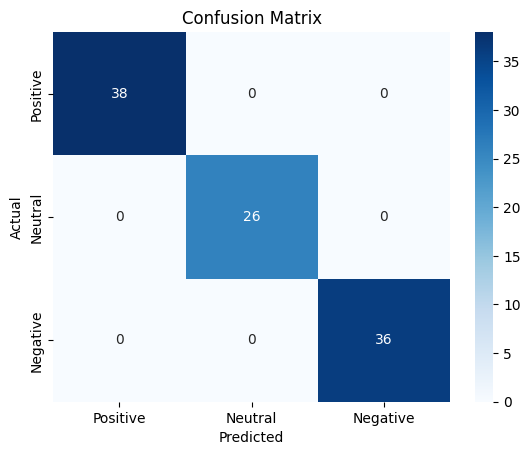

In [18]:
cm = confusion_matrix(y_test, y_pred, labels=["Positive", "Neutral", "Negative"])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Positive", "Neutral", "Negative"],
            yticklabels=["Positive", "Neutral", "Negative"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
def predict_sentiment(review):
    review_vector = vectorizer.transform([review])
    prediction = model.predict(review_vector)[0]
    return prediction

In [20]:
review1 = "The sound quality is fantastic and battery lasts long"
review2 = "It is okay not too good not too bad"
review3 = "Very poor quality and stopped working quickly"

print("Review:", review1)
print("Predicted Sentiment:", predict_sentiment(review1))

print("\nReview:", review2)
print("Predicted Sentiment:", predict_sentiment(review2))

print("\nReview:", review3)
print("Predicted Sentiment:", predict_sentiment(review3))

Review: The sound quality is fantastic and battery lasts long
Predicted Sentiment: Positive

Review: It is okay not too good not too bad
Predicted Sentiment: Neutral

Review: Very poor quality and stopped working quickly
Predicted Sentiment: Negative


In [21]:
selected_brand = "boAt"

brand_reviews = df[df["brand"] == selected_brand]

print(f"Reviews for {selected_brand}:")
brand_reviews[["product", "review", "sentiment"]]

Reviews for boAt:


,product,review,sentiment
0,Airdopes Alpha,The sound quality is really satisfying during ...,Positive
9,Airdopes Alpha,Battery life is acceptable but not outstanding.,Neutral
14,Airdopes 131,Connectivity is unreliable for the price paid.,Negative
19,Airdopes 131,Mic quality is fine for daily use for daily use.,Neutral
23,Airdopes 141,Touch controls are below expectations with wea...,Negative
...,...,...,...
468,Airdopes Alpha,The fit is okay in this price segment.,Neutral
482,Airdopes 141,The design looks fantastic and easy to pair.,Positive
493,Airdopes Alpha,Battery life is decent in this price segment.,Neutral
495,Airdopes 131,The fit is satisfactory for casual listening.,Neutral


In [22]:
brand_reviews["sentiment"].value_counts()

,count
sentiment,
Neutral,38
Positive,35
Negative,31


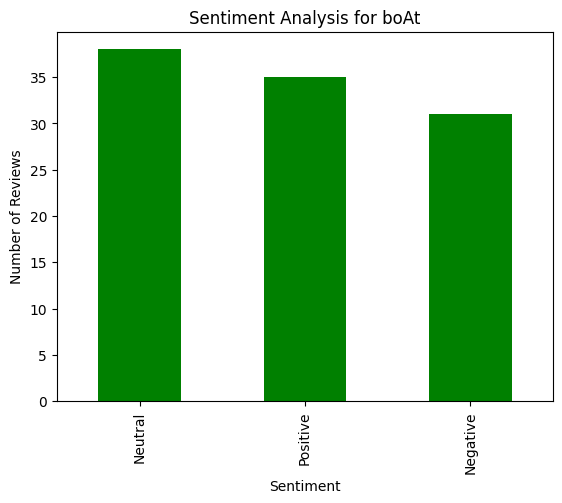

In [23]:
selected_brand = "boAt"

brand_reviews = df[df["brand"] == selected_brand]

brand_reviews["sentiment"].value_counts().plot(kind='bar',color='green')
plt.title(f"Sentiment Analysis for {selected_brand}")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

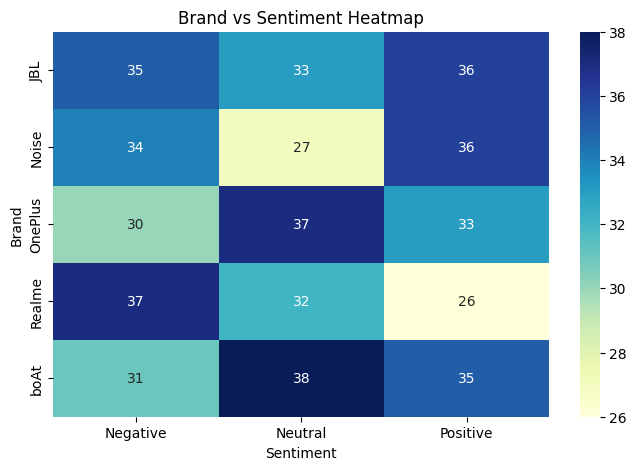

In [24]:
brand_sentiment = pd.crosstab(df["brand"], df["sentiment"])

plt.figure(figsize=(8,5))
sns.heatmap(brand_sentiment, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Brand vs Sentiment Heatmap")
plt.xlabel("Sentiment")
plt.ylabel("Brand")
plt.show()

### CONCLUSION:
####This project successfully classifies product reviews into Positive, Neutral, and Negative sentiments using TF-IDF and Logistic Regression. It helps in understanding customer opinions and provides brand-wise sentiment analysis along with visual representation of the results. The project shows the practical application of machine learning in analyzing product reviews efficiently.